# NFXP — Original Dynamic Demand Model

**Oliver Ovdal Eiberg Jørgensen & Solveig Røndal-Liniger** — Dynamic Programming, Spring 2026

---

## Model

The consumer chooses each period $t$: $y_{it} \in \{0, 1, \ldots, J\}$ — either no purchase ($y=0$) or brand $j \in \{1,\ldots,J\}$.

**State variable:** $x_{it} = (\ell_{it},\, d_{it},\, e_t)$ where
- $\ell_{it}$: last-purchased brand
- $d_{it}$: time since last purchase
- $e_t$: promotion status (exogenous Markov chain)

**Utility (equation 1):**
$$
U_{it} = \begin{cases}
  \alpha(\ell_{it}) - \beta^{\rm dep}(\ell_{it})\cdot d_{it} & \text{if } y_{it}=0 \\
  \alpha(j) - \gamma\cdot p_{it}(j) - \beta^{\rm sc}(\ell_{it},\, j) & \text{if } y_{it}=j
\end{cases}
$$

- $\beta^{\rm dep}[\ell] \times d$: inventory depreciation linear in duration, rate is brand-specific
- $\gamma \cdot p_{it}(j)$: disutility from expenditure
- $\beta^{\rm sc}(\ell, j)$: brand switching cost

**Transition rule:**
$$
(\ell_{i,t+1},\, d_{i,t+1}) = \begin{cases}
  (\ell_{it},\, d_{it}+1) & \text{if } y_{it}=0 \\
  (j,\, 1) & \text{if } y_{it}=j
\end{cases}
$$

**Estimator:** NFXP (Rust 1987) — Nelder-Mead outer loop, VFI inner loop. Because the two directional switching costs have one free normalization, MC results are reported using identified combinations / a symmetric switching-cost normalization.

## 1. Import

In [1]:
# Standard library and scientific computing imports
import time
import math
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


# 1. Simulation

## 2. Primitives and True Parameters

In [2]:
# ── Model dimensions ──────────────────────────────────────────────────────────
J     = 2       # number of brands
T     = 52      # periods per consumer
N     = 50_000  # consumers per panel
D_MAX = 51      # duration cap: d_idx ∈ {0,...,D_MAX}, paper-d ∈ {1,...,D_MAX+1}
DELTA = 0.95    # discount factor

# ── Price levels ──────────────────────────────────────────────────────────────
BASE_PRICES   = np.array([11.95, 24.95])   # regular unit prices
PROMO_DISC    = np.array([1.95,  15.67])   # promotion discount
PROMO_ENTRY   = 0.18                       # P(promotion starts)
PROMO_PERSIST = 0.0                        # P(promotion persists)

# ── True structural parameters (DGP): u(0)=α(ℓ)-β_dep[ℓ]d, u(j)=α(j)-γp(j)-β_sc(ℓ,j) ──
ALPHA_TRUE    = np.array([0.0,  0.50])           # α(1)=0 is the normalization
GAMMA_TRUE    = 0.05                             # marginal expenditure disutility
BETA_SC_TRUE  = np.array([[0.00, 0.30],          # β^sc[k,j]: switching cost k→j
                           [0.25, 0.00]])
BETA_DEP_TRUE = np.array([0.275, 0.275])         # β^dep[ℓ]: brand-specific depreciation rate

# ── Monte Carlo ───────────────────────────────────────────────────────────────
MC_REPS = 50
MC_SEED = 2024

# ── Choice indexing: c=0 is no purchase; c=j buys brand j ∈ {1,...,J} ───────
N_CHOICES = J + 1   # 3 choices: {0, 1, 2}

# ── Parameter vector ──────────────────────────────────────────────────────────
PARAM_NAMES = ["alpha_2", "gamma", "beta_sc_12", "beta_sc_21",
               "beta_dep_1", "beta_dep_2"]

THETA_TRUE = np.array([
    ALPHA_TRUE[1],
    GAMMA_TRUE,
    BETA_SC_TRUE[0, 1],
    BETA_SC_TRUE[1, 0],
    BETA_DEP_TRUE[0],
    BETA_DEP_TRUE[1],
])

print("True parameters:")
for n, v in zip(PARAM_NAMES, THETA_TRUE):
    print(f"  {n:<14} = {v}")
print(f"\nN_CHOICES={N_CHOICES}  |  BASE_PRICES={BASE_PRICES}  |  D_MAX={D_MAX}")

True parameters:
  alpha_2        = 0.5
  gamma          = 0.05
  beta_sc_12     = 0.3
  beta_sc_21     = 0.25
  beta_dep_1     = 0.275
  beta_dep_2     = 0.275

N_CHOICES=3  |  BASE_PRICES=[11.95 24.95]  |  D_MAX=51


## 3. Price Process — Hi-Lo (Assumption 2.1)

Promotion status $e_t \in \{0,1\}^J$ is a binary vector. With $J=2$ there are $2^2=4$ possible states. Brand promotions follow independent two-state Markov chains, and the joint transition probability is the product of the marginal probabilities.

In [3]:
# Enumerate all 2^J joint promotion states as binary vectors
promo_states = np.array(
    [[(s >> j) & 1 for j in range(J)] for s in range(2 ** J)], dtype=int
)
N_PROMO = len(promo_states)


# Define the transition matrix for the joint promotion process.
def make_promo_transition() -> np.ndarray:
    # Build joint transition matrix as product of independent brand Markov chains
    trans = np.empty((N_PROMO, N_PROMO))
    for s, curr in enumerate(promo_states):
        # Brand-level promotion probabilities depend on current promo status
        prob_on = np.where(curr == 1, PROMO_PERSIST, PROMO_ENTRY)
        for sp, nxt in enumerate(promo_states):
            # Joint probability is the product across independent brands
            trans[s, sp] = np.prod(np.where(nxt == 1, prob_on, 1.0 - prob_on))
    return trans


PROMO_TRANS = make_promo_transition()
# Convert each promotion state into brand-specific prices
PRICE_BY_PROMO = BASE_PRICES - PROMO_DISC * promo_states

print("Unit prices by promotion state:")
for s, e in enumerate(promo_states):
    p = PRICE_BY_PROMO[s]
    print(f"  State {s}: e={tuple(e)}  p={p}")

Unit prices by promotion state:
  State 0: e=(np.int64(0), np.int64(0))  p=[11.95 24.95]
  State 1: e=(np.int64(1), np.int64(0))  p=[10.   24.95]
  State 2: e=(np.int64(0), np.int64(1))  p=[11.95  9.28]
  State 3: e=(np.int64(1), np.int64(1))  p=[10.    9.28]


## 4. Utility Function (equation 1)

$$U_{it} = \begin{cases}
  \alpha(\ell_{it}) - \beta^{\rm dep}[\ell_{it}] \cdot d_{it} & \text{if } y_{it}=0 \\
  \alpha(j) - \gamma\cdot p_{it}(j) - \beta^{\rm sc}(\ell_{it},\, j) & \text{if } y_{it}=j
\end{cases}$$

- $\gamma \cdot p_{it}(j)$: disutility from expenditure (linear in price)
- $\beta^{\rm dep}[\ell] \times d$: inventory depreciation linear in duration, rate is brand-specific
- $\beta^{\rm sc}(\ell, j)$: brand switching cost

In [4]:
# Define deterministic one-period utility for a state-choice pair.
def flow_util(choice, last_brand, duration, e_idx,
              alpha, gamma, beta_sc, beta_dep) -> float:
    """
    Deterministic period utility.

    choice    : 0 = no purchase; j ∈ {1,...,J} → buy brand j
    last_brand: ℓ ∈ {1,...,J}
    duration  : paper-d = d_idx + 1  ∈ {1,...,D_MAX+1}
    beta_dep  : (J,) array — brand-specific depreciation rate
    """
    l      = last_brand - 1
    prices = BASE_PRICES - PROMO_DISC * promo_states[e_idx]

    if choice == 0:
        # No purchase: inventory depreciates at brand-specific rate
        return alpha[l] - beta_dep[l] * duration

    j = choice - 1   # brand index (0-indexed)
    return alpha[j] - gamma * prices[j] - beta_sc[l, j]

## 5. Inner Loop: Value Function Iteration (VFI)

**State space:** $(\ell, d, e)$, $J \times (D_{\max}+1) \times N_e = 2 \times 4 \times 4 = 32$ states.

$V$ has shape `(J, D_MAX+1, N_PROMO)`.

Transition rules in VFI:
- No purchase: $(\ell, d_{\rm idx}) \to (\ell, \min(d_{\rm idx}+1, D_{\rm MAX}))$
- Purchase $j$: $(\ell, d_{\rm idx}) \to (j, 0)$ (paper-$d=1$)

In [5]:
# Solve the dynamic program by value function iteration.
def solve_vfi(alpha, gamma, beta_sc, beta_dep,
              tol: float = 1e-10, max_iter: int = 2_000) -> np.ndarray:
    """
    VFI for the original model (brand-specific β^dep).

    V shape: (J, D_MAX+1, N_PROMO).
    d_idx ∈ {0,...,D_MAX} corresponds to paper-d = d_idx + 1.
    """
    # Create duration indexes used in the state space.
    duration_idx = np.arange(D_MAX + 1)
    # The paper's duration starts at 1, while Python indexes start at 0.
    duration = duration_idx + 1.0
    # If the consumer does not buy, duration increases but is capped at D_MAX.
    next_duration = np.minimum(duration_idx + 1, D_MAX)

    # Utility from not buying, computed for every last brand and duration.
    no_purchase_util = alpha[:, None] - beta_dep[:, None] * duration[None, :]
    # Q stores the value of each possible choice in each state.
    Q = np.empty((J, D_MAX + 1, N_PROMO, N_CHOICES))
    # Start from a zero value function and update it until convergence.
    V = np.zeros((J, D_MAX + 1, N_PROMO))

    for _ in range(max_iter):
        # Expected continuation value (integrate over promotion process)
        EV = (V.reshape(J * (D_MAX + 1), N_PROMO) @ PROMO_TRANS.T
              ).reshape(J, D_MAX + 1, N_PROMO)

        # No purchase: state → (ℓ, min(d_idx+1, D_MAX), e')
        Q[..., 0] = no_purchase_util[:, :, None] + DELTA * EV[:, next_duration, :]

        # Purchase brand j: state → (j, d_idx=0, e')  [paper d=1]
        for j_idx in range(J):
            Q[..., j_idx + 1] = (
                alpha[j_idx]
                - gamma * PRICE_BY_PROMO[:, j_idx][None, None, :]
                - beta_sc[:, j_idx][:, None, None]
                + DELTA * EV[j_idx, 0, :][None, None, :]
            )

        # Log-sum-exp for Emax; subtracting q_max keeps exponentials stable.
        q_max = Q.max(axis=3)
        V_new = q_max + np.log(np.exp(Q - q_max[..., None]).sum(axis=3))

        # Convergence means the whole value function barely changes.
        if np.max(np.abs(V_new - V)) < tol:
            return V_new
        V = V_new

    return V

## 6. Conditional Choice Probabilities (CCPs)

$$P(j \mid s;\theta) = \frac{\exp(Q_j)}{\sum_{k}\exp(Q_k)}, \quad Q_j = u(j, s) + \delta\cdot EV(\text{next state})$$

`P` shape: `(J, D_MAX+1, N_PROMO, N_CHOICES)`.

In [6]:
# Convert the solved value function into conditional choice probabilities.
def compute_ccps(V, alpha, gamma, beta_sc, beta_dep) -> np.ndarray:
    """
    Compute CCPs from solved value function V.
    P shape: (J, D_MAX+1, N_PROMO, N_CHOICES).
    """
    # Duration index d_idx is the stored state variable.
    duration_idx = np.arange(D_MAX + 1)
    # Convert d_idx to the model duration used in utility.
    duration = duration_idx + 1.0
    # No purchase moves the consumer to the next duration state.
    next_duration = np.minimum(duration_idx + 1, D_MAX)

    # Expected continuation value averages V over next promotion states.
    EV = (V.reshape(J * (D_MAX + 1), N_PROMO) @ PROMO_TRANS.T
          ).reshape(J, D_MAX + 1, N_PROMO)

    # Q has one value for each possible action: no purchase, brand 1, brand 2.
    Q = np.empty((J, D_MAX + 1, N_PROMO, N_CHOICES))
    # Flow utility from no purchase for each last brand and duration.
    no_purchase_util = alpha[:, None] - beta_dep[:, None] * duration[None, :]
    # Choice 0: no purchase, so last brand is unchanged and duration increases.
    Q[..., 0] = no_purchase_util[:, :, None] + DELTA * EV[:, next_duration, :]

    # Choices 1..J: buying a brand resets duration and sets last brand to j.
    for j_idx in range(J):
        # Purchase value = brand utility - price effect - switching cost + continuation value.
        Q[..., j_idx + 1] = (
            alpha[j_idx]
            - gamma * PRICE_BY_PROMO[:, j_idx][None, None, :]
            - beta_sc[:, j_idx][:, None, None]
            + DELTA * EV[j_idx, 0, :][None, None, :]
        )

    # Softmax maps choice values to probabilities; max subtraction avoids overflow.
    weights = np.exp(Q - Q.max(axis=3, keepdims=True))
    return weights / weights.sum(axis=3, keepdims=True)

## 7. Data Simulation

`simulate_panel` simulates a consumer panel from the model's CCPs and returns:
- `Y` ∈ {0,...,J}: brand choice (0 = no purchase)
- `L`: last-purchased brand (state variable)
- `D`: duration since last purchase, d_idx ∈ {0,...,D_MAX}
- `E_IDX`: promotion status

In [7]:
# Draw one categorical outcome from each probability row.
def _sample_rows(rng, row_probs: np.ndarray) -> np.ndarray:
    """Vectorized categorical draw: one observation per row of row_probs."""
    # Uniform draws are compared with each row's cumulative probabilities
    u = rng.random(len(row_probs))
    # Example: probabilities [0.2, 0.5, 0.3] become cutoffs [0.2, 0.7, 1.0].
    cumsum = np.cumsum(row_probs, axis=1)
    # Count how many cutoffs the draw exceeds to get the chosen category.
    return (u[:, None] > cumsum).sum(axis=1)


# Simulate choices and state histories from model-implied CCPs.
def simulate_panel(P_true: np.ndarray,
                   n_consumers: int = N, n_periods: int = T,
                   seed=None) -> dict:
    """
    Simulate consumer panel from CCPs.
    P_true shape: (J, D_MAX+1, N_PROMO, N_CHOICES).

    Returns dict: Y, L, D, E_IDX — all (n_consumers, n_periods).
    """
    # Seeded generator makes replications reproducible
    rng = np.random.default_rng(seed)

    # Pre-allocate full panel arrays: rows are consumers, columns are periods.
    Y     = np.zeros((n_consumers, n_periods), dtype=int)
    L     = np.zeros((n_consumers, n_periods), dtype=int)
    D     = np.zeros((n_consumers, n_periods), dtype=int)
    E_IDX = np.zeros((n_consumers, n_periods), dtype=int)

    # Random initial states: last brand, duration, and promotion state.
    ell   = rng.integers(1, J + 1,     size=n_consumers)
    dur   = rng.integers(0, D_MAX + 1, size=n_consumers)
    e_idx = rng.integers(0, N_PROMO,   size=n_consumers)

    # Step through periods because each choice updates next period's state
    for t in range(n_periods):
        # Record current state
        L[:, t]     = ell
        D[:, t]     = dur
        E_IDX[:, t] = e_idx

        # CCP lookup: state (ell-1, min(d,D_MAX), e) gives choice probabilities.
        probs = P_true[ell - 1, np.minimum(dur, D_MAX), e_idx, :]
        # Draw each consumer's choice from those probabilities.
        y = _sample_rows(rng, probs)
        Y[:, t] = y

        # Update state variables (transition rule).
        bought = y > 0
        ell    = np.where(bought, y, ell)                      # new brand if purchased
        # A purchase resets duration; no purchase increases it by one period.
        dur    = np.where(bought, 0, np.minimum(dur + 1, D_MAX))
        # Promotions evolve independently of the household choice
        e_idx  = _sample_rows(rng, PROMO_TRANS[e_idx])

    return {"Y": Y, "L": L, "D": D, "E_IDX": E_IDX}

## 8. Log-Likelihood and NFXP

**Log-likelihood:**
$$\ell(\theta) = \sum_{i,t} \log P(y_{it} \mid \ell_{it}, d_{it}, e_{it}; \theta)$$

**NFXP (Rust 1987):** outer Nelder-Mead minimizes $-\ell(\theta)$; inner VFI solves the Bellman equation at each candidate $\theta$. The unrestricted six-parameter estimator is used below as a diagnostic before imposing the switching-cost normalization.

**Parameter vector:**
$$\theta = [\alpha_2,\; \gamma,\; \beta^{sc}_{12},\; \beta^{sc}_{21},\; \beta^{dep}_1,\; \beta^{dep}_2]$$

In [8]:
# Raw full-sample likelihood: look up each observed choice probability and sum logs.
def log_likelihood(data: dict, P: np.ndarray) -> float:
    """Summed log-likelihood over all (i,t) observations."""
    Y, L, D, E = data["Y"], data["L"], data["D"], data["E_IDX"]
    # Pick the model probability assigned to each observed choice.
    probs = P[L - 1, D, E, Y]
    # The floor prevents log(0) if a probability is numerically zero.
    return float(np.sum(np.log(np.maximum(probs, 1e-300))))


# Aggregate state-choice cells to get the same likelihood faster inside NFXP.
def state_choice_counts(data: dict) -> np.ndarray:
    """Aggregate simulated panel observations by state and realized choice."""
    # counts[last_brand, duration, promo_state, choice] stores frequencies.
    counts = np.zeros((J, D_MAX + 1, N_PROMO, N_CHOICES), dtype=float)
    # np.add.at increments the appropriate cell for every observation.
    np.add.at(
        counts,
        (
            data["L"].ravel() - 1,
            data["D"].ravel(),
            data["E_IDX"].ravel(),
            data["Y"].ravel(),
        ),
        1.0,
    )
    return counts


# Evaluate the likelihood using aggregated state-choice counts.
def log_likelihood_counts(counts: np.ndarray, P: np.ndarray) -> float:
    """Summed log-likelihood using state-choice counts."""
    # Frequency times log probability equals the same likelihood as raw rows.
    return float(np.sum(counts * np.log(np.maximum(P, 1e-300))))


# Keep the unrestricted vector for estimation; handle identification after estimation.
def unpack(theta: np.ndarray):
    """Unpack theta = [alpha_2, gamma, beta_sc_12, beta_sc_21, beta_dep_1, beta_dep_2]."""
    # alpha_1=0 is not enough to separately identify beta_sc_12 and beta_sc_21.
    alpha    = np.array([0.0, theta[0]])
    gamma    = float(theta[1])
    beta_sc  = np.array([[0.0, theta[2]], [theta[3], 0.0]])
    beta_dep = np.array([theta[4], theta[5]])   # (J,) brand-specific rates
    return alpha, gamma, beta_sc, beta_dep


# Exact ridge: shifting alpha_2, beta_sc_12, and beta_sc_21 can leave CCPs unchanged.
def observationally_equivalent_theta(theta: np.ndarray, shift: float) -> np.ndarray:
    theta = np.asarray(theta, dtype=float).copy()
    theta[0] += (1.0 - DELTA) * shift   # alpha_2 adjusts with discounting
    theta[2] += shift                   # increase cost from brand 1 to 2
    theta[3] -= shift                   # decrease cost from brand 2 to 1
    return theta


def symmetric_switching_normalization(theta: np.ndarray) -> np.ndarray:
    """Pick the equivalent representation with beta_sc_12 = beta_sc_21."""
    # Pick a readable representative without changing likelihood or CCPs.
    theta = np.asarray(theta, dtype=float)
    shift = 0.5 * (theta[3] - theta[2])
    return observationally_equivalent_theta(theta, shift)


# True values under the same symmetric normalization used for reporting.
THETA_TRUE_NORMALIZED = symmetric_switching_normalization(THETA_TRUE)


IDENTIFIED_PARAM_NAMES = [
    "alpha2_minus_k_sc12",
    "alpha2_plus_k_sc21",
    "beta_sc_sum",
    "gamma",
    "beta_dep_1",
    "beta_dep_2",
]


def identified_theta(theta: np.ndarray) -> np.ndarray:
    """Combinations invariant to the switching-cost normalization ridge."""
    # Invariant combinations; beta_sc_sum is the two-brand beta_tilde object.
    theta = np.asarray(theta, dtype=float)
    k = 1.0 - DELTA
    return np.array([
        theta[0] - k * theta[2],
        theta[0] + k * theta[3],
        theta[2] + theta[3],
        theta[1],
        theta[4],
        theta[5],
    ])


IDENTIFIED_THETA_TRUE = identified_theta(THETA_TRUE)


# NFXP objective: solve the DP at candidate theta and evaluate the likelihood.
def nfxp_objective(theta: np.ndarray, data_or_counts) -> float:
    # Use pre-aggregated counts for an algebraically equivalent, faster likelihood.
    counts = state_choice_counts(data_or_counts) if isinstance(data_or_counts, dict) else data_or_counts
    # Convert optimizer vector into model primitives.
    alpha, gamma, beta_sc, beta_dep = unpack(theta)
    # Inner loop: solve the dynamic decision problem at this theta.
    V = solve_vfi(alpha, gamma, beta_sc, beta_dep)
    # Convert solved values into probabilities used in the likelihood.
    P = compute_ccps(V, alpha, gamma, beta_sc, beta_dep)
    return -log_likelihood_counts(counts, P)


# Estimate with NFXP and Nelder-Mead; the issue is identification, not the optimizer.
def estimate_nfxp(data: dict, theta0: np.ndarray = None, verbose: bool = False):
    """Estimate the model with NFXP (Nelder-Mead)."""
    if theta0 is None:
        # Default starting point if the caller does not provide one.
        theta0 = np.array([0.1, 0.03, 0.3, 0.3, 0.2, 0.2])
    # Aggregate once so the optimizer does not rebuild counts every call.
    counts = state_choice_counts(data)
    return minimize(
        fun=nfxp_objective,
        x0=theta0,
        args=(counts,),
        method="Nelder-Mead",
        options={"maxiter": 10_000, "xatol": 1e-5, "fatol": 1e-5,
                 "disp": verbose, "adaptive": True},
    )

## 9. Pilot — Single Panel

Verify that VFI converges, the simulation looks reasonable, and that NFXP recovers the true parameters from a single panel.

In [9]:
# Pilot run: first solve the model at the known true parameters.
print("Step 1: Solving DP at true parameters...")
# Unpack the true parameter vector into objects used by the model functions.
a0, g0, sc0, dep0 = unpack(THETA_TRUE)
# Solve the dynamic program and convert values into choice probabilities.
V_true = solve_vfi(a0, g0, sc0, dep0)
P_true = compute_ccps(V_true, a0, g0, sc0, dep0)
print("  VFI converged.")

# Simulate one artificial data set from the model-implied probabilities.
print(f"\nStep 2: Simulating panel (N={N}, T={T})...")
data_pilot = simulate_panel(P_true, seed=42)
# Y stores the realized choice in each consumer-period observation.
Y = data_pilot["Y"]
# Report simulated choice shares as a quick diagnostic of the DGP.
print(f"  No purchase: {(Y == 0).mean():.1%}")
for j in range(1, J + 1):
    print(f"  Brand {j}:     {(Y == j).mean():.1%}")

# Re-estimate parameters from the simulated data to check recovery.
print("\nStep 3: Estimating with NFXP...")
# Perturb true parameters slightly as the optimizer's starting point.
theta0_pilot = THETA_TRUE + np.array([0.05, 0.005, 0.05, 0.05, 0.02, 0.02])
# Time the nested fixed point estimation.
t0 = time.perf_counter()
res_pilot = estimate_nfxp(data_pilot, theta0=theta0_pilot)
t1 = time.perf_counter() - t0
print(f"  Time: {t1:.1f}s  |  Converged: {res_pilot.success}  |  Iterations: {res_pilot.nit}")

# Compare estimates to the true parameters used to simulate the data.
print("\n" + "─" * 55)
df_pilot = pd.DataFrame({
    "Parameter": PARAM_NAMES,
    "True":      THETA_TRUE,
    "NFXP":      res_pilot.x,
    "Bias":      res_pilot.x - THETA_TRUE,
})
print(df_pilot.to_string(index=False, float_format=lambda x: f"{x:+.4f}"))

Step 1: Solving DP at true parameters...
  VFI converged.

Step 2: Simulating panel (N=50000, T=52)...
  No purchase: 42.3%
  Brand 1:     23.5%
  Brand 2:     34.2%

Step 3: Estimating with NFXP...
  Time: 4.8s  |  Converged: True  |  Iterations: 240

───────────────────────────────────────────────────────
 Parameter    True    NFXP    Bias
   alpha_2 +0.5000 +0.4979 -0.0021
     gamma +0.0500 +0.0501 +0.0001
beta_sc_12 +0.3000 +0.2287 -0.0713
beta_sc_21 +0.2500 +0.3179 +0.0679
beta_dep_1 +0.2750 +0.2764 +0.0014
beta_dep_2 +0.2750 +0.2751 +0.0001


## 10. Monte Carlo

For each replication:
1. Simulate a new panel from the DGP
2. Estimate the model with NFXP
3. Record estimates, bias, and RMSE

**Important identification point:** the two directional switching costs are not separately identified under the current normalization. The unrestricted estimates can drift along an exact ridge, so the MC should be interpreted using identified combinations or after imposing one additional normalization.

In [10]:
# Monte Carlo stores raw unrestricted NFXP estimates; post-processing handles identification.
def run_monte_carlo(n_reps: int = MC_REPS, seed: int = MC_SEED):
    # Master RNG creates independent seeds for each replication.
    rng_master = np.random.default_rng(seed)
    rep_seeds  = rng_master.integers(0, 1_000_000, size=n_reps)

    # Solve DP once at true parameters; all replications use the same DGP CCPs
    a_t, g_t, sc_t, dep_t = unpack(THETA_TRUE)
    V_t = solve_vfi(a_t, g_t, sc_t, dep_t)
    P_t = compute_ccps(V_t, a_t, g_t, sc_t, dep_t)

    print(f"MC  |  J={J}, T={T}, N={N}, D_MAX={D_MAX}, reps={n_reps}")
    print(f"DGP: β^dep={BETA_DEP_TRUE}\n")

    rows = []
    for rep in range(1, n_reps + 1):
        # Simulate a new panel for this replication
        data = simulate_panel(P_t, n_consumers=N, n_periods=T,
                              seed=int(rep_seeds[rep - 1]))

        # Random perturbation around true parameters as starting point
        rng_s  = np.random.default_rng(int(rep_seeds[rep - 1]) + 999)
        pert   = rng_s.normal(0, 0.05, size=6)
        theta0 = THETA_TRUE + pert

        t0 = time.perf_counter()
        # Estimate with NFXP using the Nelder-Mead outer loop.
        r  = estimate_nfxp(data, theta0=theta0)
        t1 = time.perf_counter() - t0

        print(f"  Rep {rep:>3}/{n_reps}  conv={r.success}  ({t1:>4.0f}s)")

        # Store unrestricted estimates; do not interpret directional switching costs alone.
        for k, name in enumerate(PARAM_NAMES):
            rows.append({
                "rep":       rep,
                "param":     name,
                "true":      THETA_TRUE[k],
                "estimate":  r.x[k],
                "bias":      r.x[k] - THETA_TRUE[k],
                "sq_error":  (r.x[k] - THETA_TRUE[k]) ** 2,
                "converged": int(r.success),
            })

    # Summarize the unrestricted diagnostic estimates across replications.
    df = pd.DataFrame(rows)
    summary_rows = []
    for i, name in enumerate(PARAM_NAMES):
        # Work parameter-by-parameter to compute MC diagnostics.
        g = df[df["param"] == name]
        estimates = g["estimate"].dropna()
        n_rep = int(estimates.size)
        mean_est = estimates.mean()
        bias = mean_est - THETA_TRUE[i]
        std = estimates.std(ddof=1)
        se_mean = std / np.sqrt(n_rep) if n_rep > 0 else np.nan
        rmse = np.sqrt(g["sq_error"].mean())
        true_value = THETA_TRUE[i]
        # Relative bias is undefined if the true value is zero.
        relative_bias_pct = 100 * bias / true_value if not np.isclose(true_value, 0.0) else np.nan

        # Normal-approximation confidence interval for the mean estimate.
        if n_rep > 1 and np.isfinite(se_mean) and se_mean > 0:
            z_crit = 1.96
            ci95_lo = mean_est - z_crit * se_mean
            ci95_hi = mean_est + z_crit * se_mean
        else:
            ci95_lo = np.nan
            ci95_hi = np.nan

        summary_rows.append({
            "param":     name,
            "true":      THETA_TRUE[i],
            "n_rep":     n_rep,
            "mean_est":  mean_est,
            "bias":      bias,
            "rel_bias_pct": relative_bias_pct,
            "std":       std,
            "se_mean":   se_mean,
            "ci95_lo":   ci95_lo,
            "ci95_hi":   ci95_hi,
            "rmse":      rmse,
            "conv_rate": g["converged"].mean(),
        })

    summary = pd.DataFrame(summary_rows)

    return df, summary


def summarize_mc_draws(df: pd.DataFrame, param_names, true_values) -> pd.DataFrame:
    """Summarize MC draws stored in the same long format as results."""
    # Reusable summary for raw, identified, and normalized MC draws.
    summary_rows = []
    for i, name in enumerate(param_names):
        g = df[df["param"] == name]
        estimates = g["estimate"].dropna()
        n_rep = int(estimates.size)
        mean_est = estimates.mean()
        true_value = true_values[i]
        bias = mean_est - true_value
        std = estimates.std(ddof=1)
        se_mean = std / np.sqrt(n_rep) if n_rep > 0 else np.nan
        rmse = np.sqrt(((estimates - true_value) ** 2).mean())
        relative_bias_pct = 100 * bias / true_value if not np.isclose(true_value, 0.0) else np.nan

        if n_rep > 1 and np.isfinite(se_mean) and se_mean > 0:
            ci95_lo = mean_est - 1.96 * se_mean
            ci95_hi = mean_est + 1.96 * se_mean
        else:
            ci95_lo = np.nan
            ci95_hi = np.nan

        summary_rows.append({
            "param": name,
            "true": true_value,
            "n_rep": n_rep,
            "mean_est": mean_est,
            "bias": bias,
            "rel_bias_pct": relative_bias_pct,
            "std": std,
            "se_mean": se_mean,
            "ci95_lo": ci95_lo,
            "ci95_hi": ci95_hi,
            "rmse": rmse,
            "conv_rate": g["converged"].mean() if "converged" in g.columns else np.nan,
        })
    return pd.DataFrame(summary_rows)


def make_identified_mc_results(results: pd.DataFrame):
    """Convert unrestricted MC draws to normalization-invariant combinations."""
    # Rewrite estimates into ridge-invariant combinations without re-estimating.
    wide = results.pivot(index="rep", columns="param", values="estimate")
    conv = results.groupby("rep")["converged"].min()
    rows = []
    for rep, row in wide.iterrows():
        theta = row.loc[PARAM_NAMES].to_numpy(dtype=float)
        combo = identified_theta(theta)
        for k, name in enumerate(IDENTIFIED_PARAM_NAMES):
            rows.append({
                "rep": rep,
                "param": name,
                "true": IDENTIFIED_THETA_TRUE[k],
                "estimate": combo[k],
                "bias": combo[k] - IDENTIFIED_THETA_TRUE[k],
                "sq_error": (combo[k] - IDENTIFIED_THETA_TRUE[k]) ** 2,
                "converged": int(conv.loc[rep]),
            })
    identified_results = pd.DataFrame(rows)
    identified_summary = summarize_mc_draws(
        identified_results, IDENTIFIED_PARAM_NAMES, IDENTIFIED_THETA_TRUE
    )
    return identified_results, identified_summary


def make_symmetric_normalized_mc_results(results: pd.DataFrame):
    """Map each unrestricted draw to beta_sc_12 = beta_sc_21 normalization."""
    # Pick the beta_sc_12=beta_sc_21 representative without re-estimating.
    wide = results.pivot(index="rep", columns="param", values="estimate")
    conv = results.groupby("rep")["converged"].min()
    rows = []
    for rep, row in wide.iterrows():
        theta = row.loc[PARAM_NAMES].to_numpy(dtype=float)
        theta_norm = symmetric_switching_normalization(theta)
        for k, name in enumerate(PARAM_NAMES):
            rows.append({
                "rep": rep,
                "param": name,
                "true": THETA_TRUE_NORMALIZED[k],
                "estimate": theta_norm[k],
                "bias": theta_norm[k] - THETA_TRUE_NORMALIZED[k],
                "sq_error": (theta_norm[k] - THETA_TRUE_NORMALIZED[k]) ** 2,
                "converged": int(conv.loc[rep]),
            })
    normalized_results = pd.DataFrame(rows)
    normalized_summary = summarize_mc_draws(
        normalized_results, PARAM_NAMES, THETA_TRUE_NORMALIZED
    )
    return normalized_results, normalized_summary

In [11]:
# Run all Monte Carlo replications and collect raw estimates plus summaries.
results, summary = run_monte_carlo()

MC  |  J=2, T=52, N=50000, D_MAX=51, reps=50
DGP: β^dep=[0.275 0.275]

  Rep   1/50  conv=True  (   6s)
  Rep   2/50  conv=True  (   5s)
  Rep   3/50  conv=True  (   5s)
  Rep   4/50  conv=True  (   6s)
  Rep   5/50  conv=True  (   6s)
  Rep   6/50  conv=True  (   9s)
  Rep   7/50  conv=True  (   7s)
  Rep   8/50  conv=True  (   7s)
  Rep   9/50  conv=True  (   6s)
  Rep  10/50  conv=True  (   5s)
  Rep  11/50  conv=True  (   8s)
  Rep  12/50  conv=True  (   7s)
  Rep  13/50  conv=True  (   5s)
  Rep  14/50  conv=True  (   7s)
  Rep  15/50  conv=True  (   7s)
  Rep  16/50  conv=True  (   6s)
  Rep  17/50  conv=True  (   5s)
  Rep  18/50  conv=True  (   6s)
  Rep  19/50  conv=True  (   5s)
  Rep  20/50  conv=True  (   6s)
  Rep  21/50  conv=True  (   5s)
  Rep  22/50  conv=True  (   7s)
  Rep  23/50  conv=True  (   5s)
  Rep  24/50  conv=True  (   7s)
  Rep  25/50  conv=True  (   6s)
  Rep  26/50  conv=True  (   8s)
  Rep  27/50  conv=True  (   5s)
  Rep  28/50  conv=True  (   7s)
  Rep

## 11. Results

The unrestricted table below is kept as a diagnostic. If $s$ is any scalar, then
$$
\alpha_2' = \alpha_2 + (1-\delta)s,\quad
\beta^{sc\prime}_{12}=\beta^{sc}_{12}+s,\quad
\beta^{sc\prime}_{21}=\beta^{sc}_{21}-s
$$
generates the same choice probabilities. Therefore the meaningful MC evidence is in normalization-invariant combinations, or in a chosen normalization such as $\beta^{sc}_{12}=\beta^{sc}_{21}$.

In [12]:
# Print unrestricted MC metrics first, mainly as an identification diagnostic.
print("=" * 72)
print("Unrestricted NFXP Monte Carlo — diagnostic table")
# Record the simulation design next to the results for reproducibility.
print(f"J={J}, T={T}, N={N}, D_MAX={D_MAX}, reps={MC_REPS}")
print("=" * 72)
# Large directional switching-cost dispersion reflects the ridge, not failed VFI.
print(summary.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Demonstrate the ridge by constructing an observationally equivalent theta.
ridge_shift_demo = 1.7
theta_ridge_demo = observationally_equivalent_theta(THETA_TRUE, ridge_shift_demo)

# Compute CCPs at the true and shifted parameter vectors.
a_true, g_true, sc_true, dep_true = unpack(THETA_TRUE)
V_true_check = solve_vfi(a_true, g_true, sc_true, dep_true)
P_true_check = compute_ccps(V_true_check, a_true, g_true, sc_true, dep_true)

a_ridge, g_ridge, sc_ridge, dep_ridge = unpack(theta_ridge_demo)
V_ridge = solve_vfi(a_ridge, g_ridge, sc_ridge, dep_ridge)
P_ridge = compute_ccps(V_ridge, a_ridge, g_ridge, sc_ridge, dep_ridge)
# Numerical zero confirms both vectors imply the same choice probabilities.
max_ccp_diff = np.max(np.abs(P_true_check - P_ridge))

print("\nExact switching-cost ridge check")
print(f"  ridge shift s        = {ridge_shift_demo:.3f}")
print(f"  true theta           = {np.round(THETA_TRUE, 4)}")
print(f"  equivalent theta     = {np.round(theta_ridge_demo, 4)}")
print(f"  max |P_true - P_eq|  = {max_ccp_diff:.2e}")

# Convert raw MC draws into identified and normalized reporting objects.
identified_results, identified_summary = make_identified_mc_results(results)
normalized_results, normalized_summary = make_symmetric_normalized_mc_results(results)

# These combinations do not depend on where the optimizer lands on the ridge.
print("\nMonte Carlo for normalization-invariant combinations")
print(identified_summary.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# The symmetric table is easier to read but is only a reporting normalization.
print("\nMonte Carlo after symmetric switching-cost normalization")
print("Here beta_sc_12 = beta_sc_21 by normalization; only their sum was identified.")
print(normalized_summary.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

Unrestricted NFXP Monte Carlo — diagnostic table
J=2, T=52, N=50000, D_MAX=51, reps=50
     param   true  n_rep  mean_est    bias  rel_bias_pct    std  se_mean  ci95_lo  ci95_hi   rmse  conv_rate
   alpha_2 0.5000     50    0.4818 -0.0182       -3.6348 0.1264   0.0179   0.4468   0.5169 0.1264     1.0000
     gamma 0.0500     50    0.0500  0.0000        0.0352 0.0001   0.0000   0.0500   0.0501 0.0001     1.0000
beta_sc_12 0.3000     50   -0.0723 -0.3723     -124.0962 2.5255   0.3572  -0.7723   0.6277 2.5277     1.0000
beta_sc_21 0.2500     50    0.6217  0.3717      148.6932 2.5255   0.3572  -0.0783   1.3218 2.5276     1.0000
beta_dep_1 0.2750     50    0.2752  0.0002        0.0725 0.0017   0.0002   0.2747   0.2757 0.0017     1.0000
beta_dep_2 0.2750     50    0.2753  0.0003        0.0948 0.0011   0.0002   0.2749   0.2756 0.0012     1.0000

Exact switching-cost ridge check
  ridge shift s        = 1.700
  true theta           = [0.5   0.05  0.3   0.25  0.275 0.275]
  equivalent theta    

## 12. Visualization

Boxplots for the Monte Carlo estimates after imposing the symmetric switching-cost normalization. The unrestricted estimates are observationally equivalent along the ridge, so the normalized plot is the interpretable version.

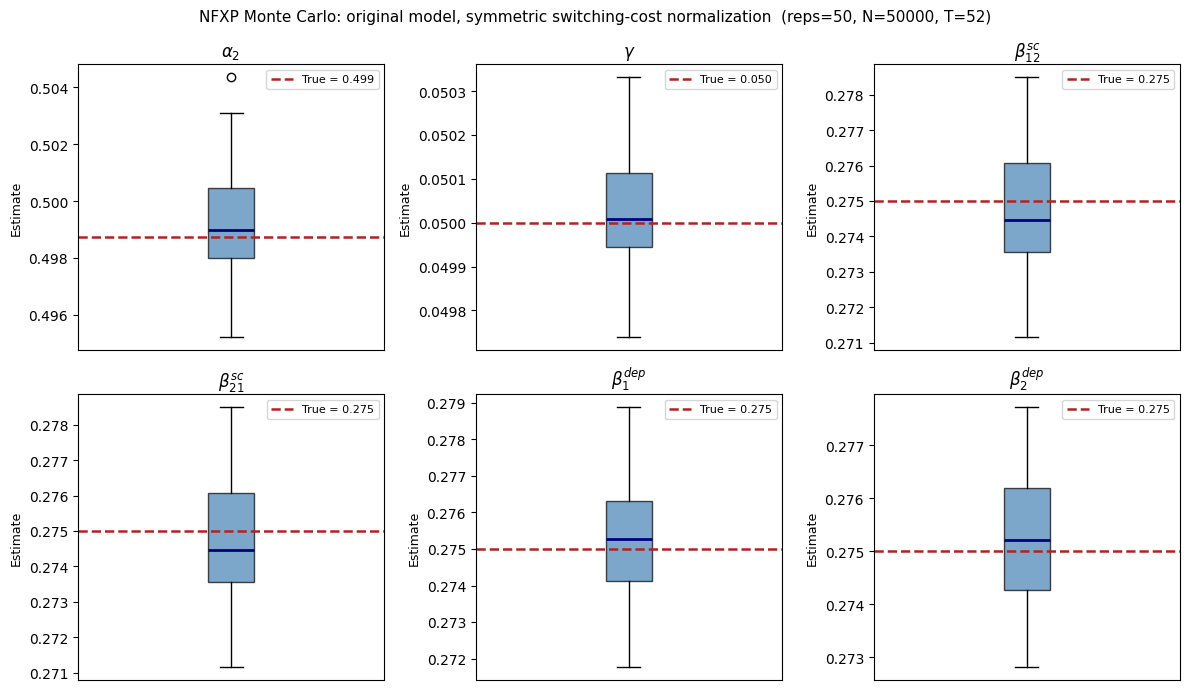

In [13]:
# LaTeX labels for each parameter (used in plots)
latex_lbl = {
    "alpha_2":    r"$\alpha_2$",
    "gamma":      r"$\gamma$",
    "beta_sc_12": r"$\beta^{sc}_{12}$",
    "beta_sc_21": r"$\beta^{sc}_{21}$",
    "beta_dep_1": r"$\beta^{dep}_1$",
    "beta_dep_2": r"$\beta^{dep}_2$",
}

# Use the normalized MC draws for presentation if the identification cell has been run.
plot_results = normalized_results if "normalized_results" in globals() else results
plot_theta_true = THETA_TRUE_NORMALIZED if "THETA_TRUE_NORMALIZED" in globals() else THETA_TRUE

# Create a 2-by-3 grid: one subplot for each estimated parameter.
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
# Flatten axes so they can be looped over like a simple list.
axes = axes.flatten()

for ax, (i, name) in zip(axes, enumerate(PARAM_NAMES)):
    # Pull all Monte Carlo estimates for the current parameter.
    est    = plot_results[plot_results["param"] == name]["estimate"].to_numpy()
    # The horizontal reference line is the true DGP value.
    true_v = plot_theta_true[i]
    # Box shows distribution of MC estimates; dashed line marks true value
    ax.boxplot(est, vert=True, patch_artist=True,
               boxprops=dict(facecolor="steelblue", alpha=0.7),
               medianprops=dict(color="navy", linewidth=2))
    ax.axhline(true_v, color="firebrick", lw=1.8, ls="--",
               label=f"True = {true_v:.3f}")
    # Use mathematical labels for readability in the figure.
    ax.set_title(latex_lbl.get(name, name), fontsize=12)
    ax.set_ylabel("Estimate", fontsize=9)
    ax.legend(fontsize=8)
    # Hide meaningless x-axis ticks; each subplot has only one box.
    ax.xaxis.set_major_locator(mticker.NullLocator())

# Add one shared title describing the Monte Carlo design.
fig.suptitle(
    r"NFXP Monte Carlo: original model, symmetric switching-cost normalization"
    f"  (reps={MC_REPS}, N={N}, T={T})",
    fontsize=11,
)
# Tighten layout and save the figure for use in the paper.
plt.tight_layout()
plt.savefig("nfxp_mc_boxplots_original.pdf", bbox_inches="tight")
plt.show()

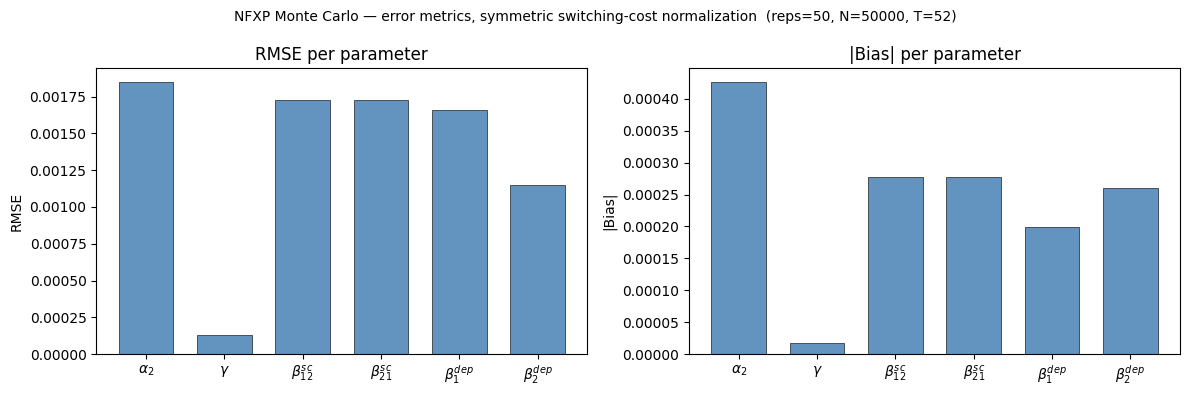

In [14]:
# Bias and RMSE bar chart; use normalized summary for presentation if available.
plot_summary = normalized_summary if "normalized_summary" in globals() else summary
# Reuse the LaTeX parameter labels from the boxplot figure.
labels   = [latex_lbl.get(n, n) for n in PARAM_NAMES]
# Absolute bias measures average signed error in magnitude.
bias_abs = [abs(plot_summary.loc[plot_summary["param"] == n, "bias"].values[0]) for n in PARAM_NAMES]
# RMSE combines bias and Monte Carlo variation.
rmse_v   = [plot_summary.loc[plot_summary["param"] == n, "rmse"].values[0]      for n in PARAM_NAMES]

# x positions are shared by both bar charts.
x = np.arange(len(PARAM_NAMES))
w = 0.35

# Make two side-by-side panels: RMSE and absolute bias.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Draw the same bar-chart structure for each metric.
for ax, vals, ylabel, title in [
    (axes[0], rmse_v,   "RMSE",   "RMSE per parameter"),
    (axes[1], bias_abs, "|Bias|", "|Bias| per parameter"),
]:
    ax.bar(x, vals, 2 * w, color="steelblue", alpha=0.85, edgecolor="black", lw=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    # Zero line anchors the scale visually.
    ax.axhline(0, color="black", lw=0.5)

# Shared title records the model and simulation design.
fig.suptitle(
    r"NFXP Monte Carlo — error metrics, symmetric switching-cost normalization"
    f"  (reps={MC_REPS}, N={N}, T={T})",
    fontsize=10,
)
# Tight layout avoids label clipping before saving.
plt.tight_layout()
plt.savefig("nfxp_mc_bias_rmse_original.pdf", bbox_inches="tight")
plt.show()

# 2. Emipirical Application

In [15]:
SCANNER_DATA = "/Users/olivereiberg/Documents/Economics/MA/2_Semester/Data/panel_with_state.csv"
PRICE_PROMO_DATA = "/Users/olivereiberg/Documents/Economics/MA/2_Semester/Data/Price_Promo.xlsx"

EMPIRICAL_BRANDS = [1, 2]
EMPIRICAL_PRICE_COLUMNS = {
    1: "Brand_1_price",
    2: "Brand_2_price",
}

# Load scanner panel
netto_df = pd.read_csv(SCANNER_DATA)

# Match current QMD setup
netto_df = netto_df[netto_df["week_num"] != 53].copy()

# Standardize key scanner columns before merging.
netto_df["Brand"] = netto_df["Brand"].astype(str)
netto_df["Price"] = pd.to_numeric(netto_df["Price"], errors="coerce").round(1)
netto_df["Customer_ID"] = pd.to_numeric(netto_df["Customer_ID"], errors="coerce").astype("Int64")
netto_df["week_num"] = pd.to_numeric(netto_df["week_num"], errors="coerce").astype("Int64")
netto_df["brand_id"] = pd.to_numeric(netto_df["Brand"], errors="coerce").fillna(0).astype(int)

# Load third Excel sheet with RRP/discount/promo data
price_promo_workbook = pd.ExcelFile(PRICE_PROMO_DATA)
price_promo_sheet_name = price_promo_workbook.sheet_names[2]
price_promo_df = pd.read_excel(price_promo_workbook, sheet_name=price_promo_sheet_name)

# Keep only the workbook columns needed below.
price_promo_required_columns = [
    "WeekNum",
    "RRP_Brand_1",
    "Discount_Brand_1",
    "Promo_Brand_1",
    "RRP_Brand_2",
    "Discount_Brand_2",
    "Promo_Brand_2",
]

price_promo_df = price_promo_df[price_promo_required_columns].copy()

for column in price_promo_required_columns:
    price_promo_df[column] = pd.to_numeric(price_promo_df[column], errors="coerce")

price_promo_df = price_promo_df.dropna(subset=["WeekNum"]).copy()
price_promo_df["WeekNum"] = price_promo_df["WeekNum"].astype(int)

# Binary offered prices: RRP if not promoted, brand-specific mean discount if promoted.
EMPIRICAL_MEAN_DISCOUNT_PRICE = {}

for brand in EMPIRICAL_BRANDS:
    promo_column = f"Promo_Brand_{brand}"
    discount_column = f"Discount_Brand_{brand}"
    rrp_column = f"RRP_Brand_{brand}"
    price_column = EMPIRICAL_PRICE_COLUMNS[brand]
    mean_discount_column = f"Mean_Discount_Brand_{brand}"

    price_promo_df[promo_column] = price_promo_df[promo_column].fillna(0).astype(int)
    promo_discount_mask = (price_promo_df[promo_column] == 1) & price_promo_df[discount_column].notna()
    mean_discount_price = price_promo_df.loc[promo_discount_mask, discount_column].mean()
    # Fall back if no promoted discount prices are observed.
    if not np.isfinite(mean_discount_price):
        mean_discount_price = price_promo_df[discount_column].mean()
    if not np.isfinite(mean_discount_price):
        mean_discount_price = price_promo_df[rrp_column].median()

    EMPIRICAL_MEAN_DISCOUNT_PRICE[brand] = mean_discount_price
    price_promo_df[mean_discount_column] = mean_discount_price
    price_promo_df[price_column] = np.where(
        price_promo_df[promo_column] == 1,
        mean_discount_price,
        price_promo_df[rrp_column],
    )

# Check the resulting binary price support.
empirical_binary_price_summary = pd.DataFrame(
    [
        {
            "Brand": brand,
            "RRP median": price_promo_df[f"RRP_Brand_{brand}"].median(),
            "Mean sale price": EMPIRICAL_MEAN_DISCOUNT_PRICE[brand],
            "Promo weeks": int(price_promo_df[f"Promo_Brand_{brand}"].sum()),
        }
        for brand in EMPIRICAL_BRANDS
    ]
)
print("Binary empirical price support:")
print(empirical_binary_price_summary.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

price_promo_merge_columns = [
    "WeekNum",
    "RRP_Brand_1",
    "Discount_Brand_1",
    "Mean_Discount_Brand_1",
    "Promo_Brand_1",
    "Brand_1_price",
    "RRP_Brand_2",
    "Discount_Brand_2",
    "Mean_Discount_Brand_2",
    "Promo_Brand_2",
    "Brand_2_price",
]

# Join weekly price/promo data onto scanner panel
netto_df = netto_df.merge(
    price_promo_df[price_promo_merge_columns],
    left_on="week_num",
    right_on="WeekNum",
    how="left",
    validate="many_to_one",
)

# Keep only rows with both alternative prices available
netto_df = netto_df.loc[
    netto_df["Brand_1_price"].notna() & netto_df["Brand_2_price"].notna()
].copy()

netto_df.head()




Binary empirical price support:
 Brand  RRP median  Mean sale price  Promo weeks
     1      24.950            9.842           10
     2      11.950            9.993            6


,Unnamed: 0,Customer_ID,week_num,y,Brand,Quantity,promo_flag,Price,last_purchase_week,duration,...,RRP_Brand_1,Discount_Brand_1,Mean_Discount_Brand_1,Promo_Brand_1,Brand_1_price,RRP_Brand_2,Discount_Brand_2,Mean_Discount_Brand_2,Promo_Brand_2,Brand_2_price
0,1,1,1,0,0,0,0,NaN,NaN,NaN,...,24.95,NaN,9.842316,0,24.95,11.95,NaN,9.99284,0,11.95
1,2,1,2,0,0,0,0,NaN,NaN,NaN,...,24.95,NaN,9.842316,0,24.95,11.95,NaN,9.99284,0,11.95
2,3,1,3,0,0,0,0,NaN,NaN,NaN,...,24.95,NaN,9.842316,0,24.95,11.95,NaN,9.99284,0,11.95
3,4,1,4,0,0,0,0,NaN,NaN,NaN,...,24.95,NaN,9.842316,0,24.95,11.95,NaN,9.99284,0,11.95
4,5,1,5,0,0,0,0,NaN,NaN,NaN,...,24.95,NaN,9.842316,0,24.95,11.95,NaN,9.99284,0,11.95


### Empirical Model Setup

In [16]:
# Empirical NFXP setup: original state and state-choice-count likelihood.

EMPIRICAL_D_MAX = D_MAX
EMPIRICAL_DELTA = DELTA
EMPIRICAL_TRANSITION_SMOOTHING = 1e-3
EMPIRICAL_VFI_TOL = 3e-8
EMPIRICAL_VFI_MAXITER = 1_000
EMPIRICAL_OPTIMIZER_MAXITER = 80

EMPIRICAL_PARAM_NAMES = ["alpha_0", *PARAM_NAMES]

EMPIRICAL_PARAM_BOUNDS = [
    (-10.0, 10.0),  # alpha_0: no-purchase intercept
    (-5.0, 5.0),    # alpha_2
    (1e-5, 1.0),    # gamma > 0
    (0.0, 5.0),     # beta_sc_12 >= 0
    (0.0, 5.0),     # beta_sc_21 >= 0
    (0.0, 5.0),     # beta_dep_1 >= 0
    (0.0, 5.0),     # beta_dep_2 >= 0
]

# Multiple starts reduce sensitivity to local optima.
EMPIRICAL_THETA_STARTS = [
    np.array([2.00, 0.50, 0.05, 0.30, 0.25, 0.20, 0.20]),
    np.array([1.50, 1.00, 0.03, 0.10, 0.10, 0.05, 0.05]),
    np.array([2.50, 0.00, 0.08, 0.50, 0.50, 0.20, 0.20]),
]


# Unpack empirical parameters, including the no-purchase intercept.
def unpack_empirical(theta: np.ndarray):
    """Unpack empirical theta with a no-purchase intercept alpha_0."""
    alpha_0 = float(theta[0])
    alpha, gamma, beta_sc, beta_dep = unpack(theta[1:])
    return alpha_0, alpha, gamma, beta_sc, beta_dep


# Convert empirical promo columns into the shared promotion-state index.
def empirical_promo_state_index(frame: pd.DataFrame) -> np.ndarray:
    """Map Promo_Brand_1/2 columns to the promo_states index used above."""
    promo_columns = [f"Promo_Brand_{brand}" for brand in EMPIRICAL_BRANDS]
    promo_matrix = frame[promo_columns].fillna(0).astype(int).to_numpy()
    # Binary promo vector maps to the shared promo state index.
    return promo_matrix @ (2 ** np.arange(J))


# Build one weekly price/promotion row per calendar week.
def make_empirical_weekly_state_table(data: pd.DataFrame) -> pd.DataFrame:
    weekly_columns = [
        "week_num",
        "Brand_1_price",
        "Brand_2_price",
        "Promo_Brand_1",
        "Promo_Brand_2",
    ]
    missing_columns = [column for column in weekly_columns if column not in data.columns]
    if missing_columns:
        raise ValueError(
            "netto_df is missing required empirical NFXP columns: "
            + ", ".join(missing_columns)
        )

    # Collapse panel rows to one weekly price/promo state.
    weekly = (
        data[weekly_columns]
        .dropna()
        .drop_duplicates()
        .sort_values("week_num")
        .reset_index(drop=True)
    )
    if weekly["week_num"].duplicated().any():
        duplicated_weeks = weekly.loc[weekly["week_num"].duplicated(), "week_num"].tolist()
        raise ValueError(f"Conflicting weekly price/promo rows for weeks: {duplicated_weeks}")

    weekly["promo_idx"] = empirical_promo_state_index(weekly)
    return weekly


# Estimate the empirical promotion Markov transition matrix.
def estimate_empirical_promo_transition(
    weekly_state: pd.DataFrame,
    smoothing: float = EMPIRICAL_TRANSITION_SMOOTHING,
) -> np.ndarray:
    """Estimate the Markov transition matrix of weekly promotion states."""
    promo_idx = weekly_state["promo_idx"].to_numpy(dtype=int)
    # Smoothing keeps unobserved transitions possible.
    transition_counts = np.full((N_PROMO, N_PROMO), smoothing, dtype=float)
    np.add.at(transition_counts, (promo_idx[:-1], promo_idx[1:]), 1.0)
    return transition_counts / transition_counts.sum(axis=1, keepdims=True)


# Build empirical prices for each joint promotion state.
def make_empirical_price_by_promo(weekly_state: pd.DataFrame) -> np.ndarray:
    """Median offered prices by joint promotion state, with own-promo fallbacks."""
    price_by_promo = np.full((N_PROMO, J), np.nan)

    for state_idx in range(N_PROMO):
        state_rows = weekly_state.loc[weekly_state["promo_idx"] == state_idx]
        if len(state_rows) == 0:
            continue
        for brand_idx, brand in enumerate(EMPIRICAL_BRANDS):
            price_by_promo[state_idx, brand_idx] = state_rows[
                EMPIRICAL_PRICE_COLUMNS[brand]
            ].median()

    # Fill missing joint states using own-promo price medians.
    for state_idx, promo_vector in enumerate(promo_states):
        for brand_idx, brand in enumerate(EMPIRICAL_BRANDS):
            if np.isfinite(price_by_promo[state_idx, brand_idx]):
                continue

            price_column = EMPIRICAL_PRICE_COLUMNS[brand]
            promo_column = f"Promo_Brand_{brand}"
            fallback = weekly_state.loc[
                weekly_state[promo_column].astype(int) == int(promo_vector[brand_idx]),
                price_column,
            ].median()
            if not np.isfinite(fallback):
                fallback = weekly_state[price_column].median()
            price_by_promo[state_idx, brand_idx] = fallback

    return price_by_promo


empirical_weekly_state = make_empirical_weekly_state_table(netto_df)
EMPIRICAL_PROMO_TRANS = estimate_empirical_promo_transition(empirical_weekly_state)
EMPIRICAL_PRICE_BY_PROMO = make_empirical_price_by_promo(empirical_weekly_state)

# Format price and transition diagnostics.
promo_state_labels = [f"e={tuple(int(v) for v in row)}" for row in promo_states]
empirical_price_by_state_table = pd.DataFrame(
    EMPIRICAL_PRICE_BY_PROMO,
    index=promo_state_labels,
    columns=["Brand 1 price", "Brand 2 price"],
)
empirical_promo_transition_table = pd.DataFrame(
    EMPIRICAL_PROMO_TRANS,
    index=promo_state_labels,
    columns=promo_state_labels,
)

print("Empirical median prices by promotion state:")
print(empirical_price_by_state_table.to_string(float_format=lambda x: f"{x:.3f}"))
print("\nEstimated weekly promotion transition matrix:")
print(empirical_promo_transition_table.to_string(float_format=lambda x: f"{x:.3f}"))


Empirical median prices by promotion state:
          Brand 1 price  Brand 2 price
e=(0, 0)         24.950         11.950
e=(1, 0)          9.842         11.950
e=(0, 1)         24.950          9.993
e=(1, 1)          9.842          9.993

Estimated weekly promotion transition matrix:
          e=(0, 0)  e=(1, 0)  e=(0, 1)  e=(1, 1)
e=(0, 0)     0.722     0.167     0.083     0.028
e=(1, 0)     0.666     0.222     0.111     0.000
e=(0, 1)     0.600     0.200     0.200     0.000
e=(1, 1)     0.997     0.001     0.001     0.001


In [17]:
# Reconstruct empirical NFXP states and aggregate counts.
def prepare_empirical_nfxp_panel(
    data: pd.DataFrame,
    d_max: int = EMPIRICAL_D_MAX,
):
    """Reconstruct the original model's start-of-period states from netto_df."""
    # These columns are needed to define choices, states, prices, and promotions.
    required_columns = [
        "Customer_ID",
        "week_num",
        "brand_id",
        "Promo_Brand_1",
        "Promo_Brand_2",
        "Brand_1_price",
        "Brand_2_price",
    ]
    missing_columns = [column for column in required_columns if column not in data.columns]
    if missing_columns:
        raise ValueError(
            "netto_df is missing required empirical NFXP columns: "
            + ", ".join(missing_columns)
        )

    # Sorting ensures lagged states are computed in calendar order per household.
    panel = data.sort_values(["Customer_ID", "week_num"]).copy()
    # Treat non-target brands as no purchase.
    panel["choice"] = panel["brand_id"].where(
        panel["brand_id"].isin(EMPIRICAL_BRANDS),
        0,
    ).astype(int)

    # Purchases are the only rows that update the last-purchased brand state.
    panel["purchase_brand"] = panel["choice"].where(panel["choice"] > 0)
    panel["purchase_week"] = panel["week_num"].where(panel["choice"] > 0)

    household_groups = panel.groupby("Customer_ID", sort=False)
    # Forward-fill gives the most recent purchase up to the current week.
    panel["last_purchase_brand_including_current"] = household_groups["purchase_brand"].ffill()
    panel["last_purchase_week_including_current"] = household_groups["purchase_week"].ffill()

    # Shift to recover the start-of-period state.
    panel["pre_last_brand"] = household_groups[
        "last_purchase_brand_including_current"
    ].shift(1)
    panel["pre_last_purchase_week"] = household_groups[
        "last_purchase_week_including_current"
    ].shift(1)
    panel["pre_duration_weeks"] = panel["week_num"] - panel["pre_last_purchase_week"]

    # Drop rows before a previous purchase is observed.
    usable = panel.loc[
        panel["pre_last_brand"].isin(EMPIRICAL_BRANDS)
        & panel["pre_duration_weeks"].notna()
        & panel["Promo_Brand_1"].notna()
        & panel["Promo_Brand_2"].notna()
    ].copy()

    usable["Y"] = usable["choice"].astype(int)
    # L is the last brand before the current choice is made.
    usable["L"] = usable["pre_last_brand"].astype(int)
    # In the simulated model, D=0 corresponds to paper duration d=1.
    usable["D"] = np.clip(
        usable["pre_duration_weeks"].to_numpy(dtype=float) - 1.0,
        0,
        d_max,
    ).astype(int)
    # E_IDX is the joint promotion-state index used by the DP arrays.
    usable["E_IDX"] = empirical_promo_state_index(usable)

    # Aggregate repeated state-choice observations for speed.
    counts = np.zeros((J, d_max + 1, N_PROMO, N_CHOICES), dtype=float)
    np.add.at(
        counts,
        (
            usable["L"].to_numpy(dtype=int) - 1,
            usable["D"].to_numpy(dtype=int),
            usable["E_IDX"].to_numpy(dtype=int),
            usable["Y"].to_numpy(dtype=int),
        ),
        1.0,
    )

    # Keep raw arrays for diagnostics and direct likelihood checks.
    data_dict = {
        "Y": usable["Y"].to_numpy(dtype=int),
        "L": usable["L"].to_numpy(dtype=int),
        "D": usable["D"].to_numpy(dtype=int),
        "E_IDX": usable["E_IDX"].to_numpy(dtype=int),
    }

    return usable, data_dict, counts


empirical_panel, empirical_data, empirical_counts = prepare_empirical_nfxp_panel(netto_df)
empirical_n_obs = int(empirical_counts.sum())

# Summarize how much data survives the state reconstruction.
empirical_sample_summary = pd.DataFrame(
    {
        "Statistic": [
            "Households in netto_df",
            "Weeks in netto_df",
            "Rows in netto_df",
            "Usable NFXP observations",
            "Rows before first observed purchase",
            "No-purchase choices",
            "Brand 1 choices",
            "Brand 2 choices",
            "Duration cap",
            "Share duration-capped",
        ],
        "Value": [
            f"{netto_df['Customer_ID'].nunique():,}",
            f"{netto_df['week_num'].nunique():,}",
            f"{len(netto_df):,}",
            f"{empirical_n_obs:,}",
            f"{len(netto_df) - empirical_n_obs:,}",
            f"{(empirical_panel['Y'] == 0).sum():,}",
            f"{(empirical_panel['Y'] == 1).sum():,}",
            f"{(empirical_panel['Y'] == 2).sum():,}",
            EMPIRICAL_D_MAX,
            f"{(empirical_panel['D'] == EMPIRICAL_D_MAX).mean():.1%}",
        ],
    }
)

print(empirical_sample_summary.to_string(index=False))


                          Statistic     Value
             Households in netto_df    42,816
                  Weeks in netto_df        52
                   Rows in netto_df 2,226,432
           Usable NFXP observations 1,697,631
Rows before first observed purchase   528,801
                No-purchase choices 1,439,420
                    Brand 1 choices    57,203
                    Brand 2 choices   201,008
                       Duration cap        51
              Share duration-capped      0.0%


In [18]:
# Solve the empirical Bellman equation at candidate parameters.
def solve_empirical_vfi(
    alpha_0,
    alpha,
    gamma,
    beta_sc,
    beta_dep,
    promo_transition: np.ndarray = EMPIRICAL_PROMO_TRANS,
    price_by_promo: np.ndarray = EMPIRICAL_PRICE_BY_PROMO,
    tol: float = EMPIRICAL_VFI_TOL,
    max_iter: int = EMPIRICAL_VFI_MAXITER,
    return_info: bool = False,
):
    """Inner loop for the empirical original model."""
    # V has one value for each last brand, duration, and promotion state.
    V = np.zeros((J, EMPIRICAL_D_MAX + 1, N_PROMO))
    # Track the largest absolute update between iterations.
    last_diff = np.inf

    for iteration in range(1, max_iter + 1):
        # Integrate over next week's promotion state.
        EV = (
            V.reshape(J * (EMPIRICAL_D_MAX + 1), N_PROMO) @ promo_transition.T
        ).reshape(J, EMPIRICAL_D_MAX + 1, N_PROMO)
        V_new = np.empty_like(V)

        # Loop over the discrete state space and update Emax.
        for last_idx in range(J):
            for duration_idx in range(EMPIRICAL_D_MAX + 1):
                # No purchase advances duration, but not beyond the cap.
                next_duration = min(duration_idx + 1, EMPIRICAL_D_MAX)
                # Convert zero-based duration index to model duration.
                paper_duration = duration_idx + 1

                for promo_idx in range(N_PROMO):
                    # Q stores the values of all choices in the current state.
                    Q = np.empty(N_CHOICES)
                    # No purchase keeps last brand and advances duration.
                    Q[0] = (
                        alpha_0
                        + alpha[last_idx]
                        - beta_dep[last_idx] * paper_duration
                        + EMPIRICAL_DELTA * EV[last_idx, next_duration, promo_idx]
                    )
                    # Purchases reset duration and switch last brand.
                    for brand_idx in range(J):
                        Q[brand_idx + 1] = (
                            alpha[brand_idx]
                            - gamma * price_by_promo[promo_idx, brand_idx]
                            - beta_sc[last_idx, brand_idx]
                            + EMPIRICAL_DELTA * EV[brand_idx, 0, promo_idx]
                        )

                    # Log-sum-exp gives expected max value under logit shocks.
                    q_max = Q.max()
                    V_new[last_idx, duration_idx, promo_idx] = q_max + np.log(
                        np.exp(Q - q_max).sum()
                    )

        last_diff = float(np.max(np.abs(V_new - V)))
        # Stop once the value function changes little enough.
        if last_diff < tol:
            if return_info:
                return V_new, {
                    "converged": True,
                    "iterations": iteration,
                    "sup_norm": last_diff,
                }
            return V_new
        V = V_new

    if return_info:
        return V, {
            "converged": False,
            "iterations": max_iter,
            "sup_norm": last_diff,
        }
    return V


# Convert empirical value functions into predicted choice probabilities.
def compute_empirical_ccps(
    V,
    alpha_0,
    alpha,
    gamma,
    beta_sc,
    beta_dep,
    promo_transition: np.ndarray = EMPIRICAL_PROMO_TRANS,
    price_by_promo: np.ndarray = EMPIRICAL_PRICE_BY_PROMO,
) -> np.ndarray:
    """Choice probabilities for the empirical original model."""
    # Use the solved V to compute future value averaged over promotions.
    EV = (
        V.reshape(J * (EMPIRICAL_D_MAX + 1), N_PROMO) @ promo_transition.T
    ).reshape(J, EMPIRICAL_D_MAX + 1, N_PROMO)
    # P will store probabilities for no purchase and each brand purchase.
    P = np.empty((J, EMPIRICAL_D_MAX + 1, N_PROMO, N_CHOICES))

    # Rebuild choice-specific values from solved V.
    for last_idx in range(J):
        for duration_idx in range(EMPIRICAL_D_MAX + 1):
            next_duration = min(duration_idx + 1, EMPIRICAL_D_MAX)
            paper_duration = duration_idx + 1

            for promo_idx in range(N_PROMO):
                Q = np.empty(N_CHOICES)
                # Choice 0 is no purchase: duration increases, brand stays fixed.
                Q[0] = (
                    alpha_0
                    + alpha[last_idx]
                    - beta_dep[last_idx] * paper_duration
                    + EMPIRICAL_DELTA * EV[last_idx, next_duration, promo_idx]
                )
                # Other choices are purchases: duration resets to zero.
                for brand_idx in range(J):
                    Q[brand_idx + 1] = (
                        alpha[brand_idx]
                        - gamma * price_by_promo[promo_idx, brand_idx]
                        - beta_sc[last_idx, brand_idx]
                        + EMPIRICAL_DELTA * EV[brand_idx, 0, promo_idx]
                    )

                # Softmax converts values into CCPs.
                weights = np.exp(Q - Q.max())
                P[last_idx, duration_idx, promo_idx, :] = weights / weights.sum()

    return P


# Evaluate empirical log-likelihood from state-choice counts.
def empirical_log_likelihood_counts(counts: np.ndarray, P: np.ndarray) -> float:
    # Counts weight each state-choice log probability by observed frequency.
    return float(np.sum(counts * np.log(np.maximum(P, 1e-300))))


# Define the empirical NFXP objective for the outer optimizer.
def empirical_nfxp_objective(
    theta: np.ndarray,
    counts: np.ndarray = empirical_counts,
    promo_transition: np.ndarray = EMPIRICAL_PROMO_TRANS,
    price_by_promo: np.ndarray = EMPIRICAL_PRICE_BY_PROMO,
) -> float:
    """Average negative log-likelihood. The inner loop is VFI."""
    # Optimizers may try invalid values; penalize non-finite candidates.
    theta = np.asarray(theta, dtype=float)
    if not np.all(np.isfinite(theta)):
        return 1e10

    alpha_0, alpha, gamma, beta_sc, beta_dep = unpack_empirical(theta)
    # Inner loop: solve DP at candidate parameters.
    V = solve_empirical_vfi(
        alpha_0,
        alpha,
        gamma,
        beta_sc,
        beta_dep,
        promo_transition=promo_transition,
        price_by_promo=price_by_promo,
    )
    P = compute_empirical_ccps(
        V,
        alpha_0,
        alpha,
        gamma,
        beta_sc,
        beta_dep,
        promo_transition=promo_transition,
        price_by_promo=price_by_promo,
    )
    # Divide by observations so the objective is on a per-observation scale.
    return -empirical_log_likelihood_counts(counts, P) / counts.sum()
